In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack, csr_matrix

import xgboost as xgb
import lightgbm as lgb

In [2]:
train = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Columns:", train.columns.tolist())

Train shape: (198000, 15)
Test shape: (102000, 14)
Columns: ['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']


created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Label distribution:
 label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64


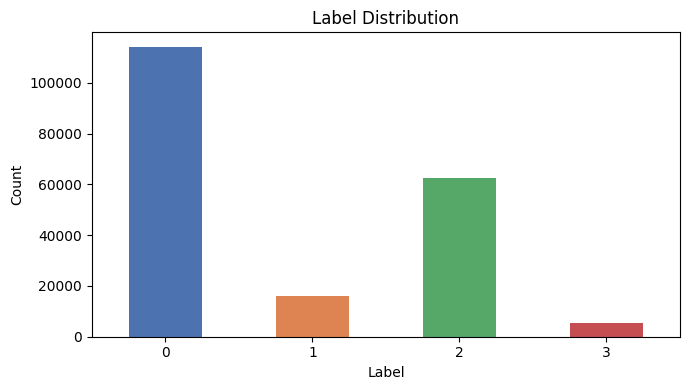


Mean upvotes by label:
 label
0    2.404833
1    2.850107
2    2.967825
3    2.035656
Name: upvote, dtype: float64

Mean downvotes by label:
 label
0    0.575294
1    0.802048
2    0.811723
3    0.514171
Name: downvote, dtype: float64


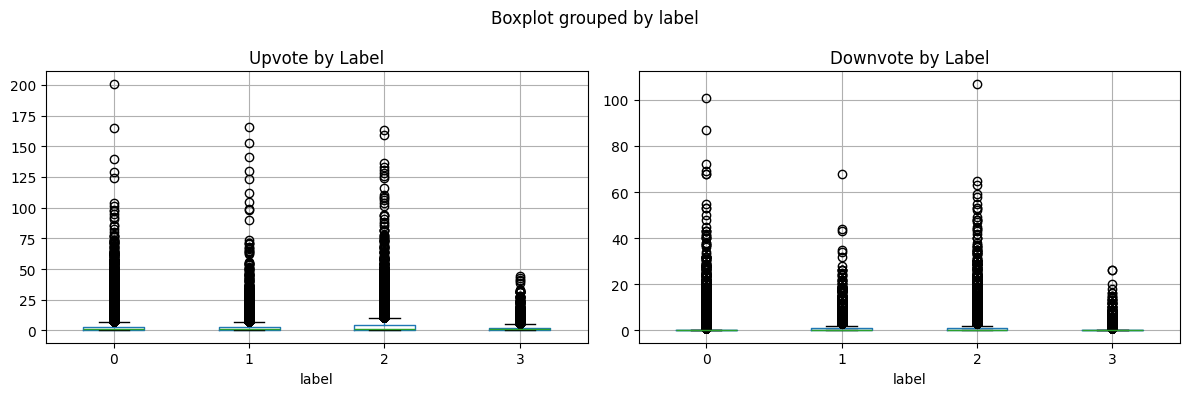

In [3]:
print(train.isnull().sum())
print("\nLabel distribution:\n", train['label'].value_counts().sort_index())

train['label'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'], figsize=(7,4))
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('label_dist.png')
plt.show()

print("\nMean upvotes by label:\n", train.groupby('label')['upvote'].mean())
print("\nMean downvotes by label:\n", train.groupby('label')['downvote'].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.boxplot(column='upvote', by='label', ax=axes[0])
axes[0].set_title('Upvote by Label')
train.boxplot(column='downvote', by='label', ax=axes[1])
axes[1].set_title('Downvote by Label')
plt.tight_layout()
plt.savefig('votes_by_label.png')
plt.show()

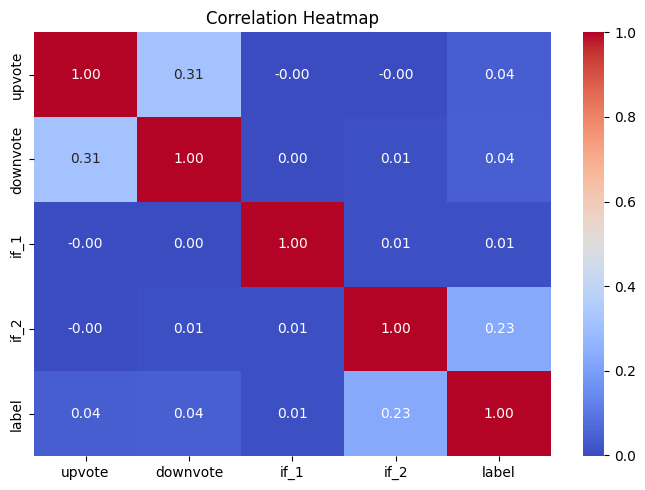

Mean comment length by label:
 label
0    295.897279
1    335.709700
2    316.893418
3    194.171695
Name: comment_length, dtype: float64


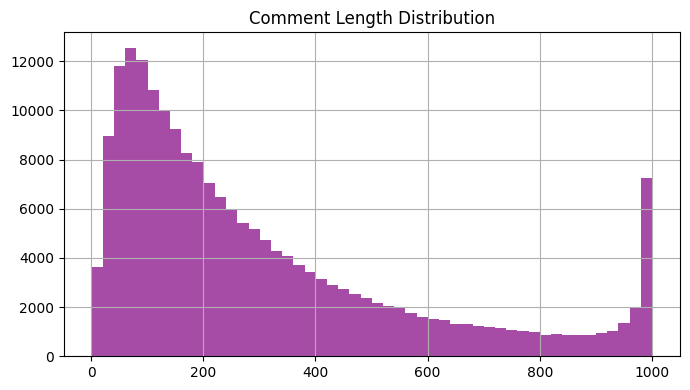

In [4]:
num_cols = [c for c in ['upvote','downvote','if_1','if_2','label'] if c in train.columns]
plt.figure(figsize=(7, 5))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('corr_heatmap.png')
plt.show()

train['comment_length'] = train['comment'].astype(str).apply(len)
print("Mean comment length by label:\n", train.groupby('label')['comment_length'].mean())

train['comment_length'].clip(0, 1000).hist(bins=50, color='purple', alpha=0.7, figsize=(7,4))
plt.title('Comment Length Distribution')
plt.tight_layout()
plt.savefig('comment_length.png')
plt.show()

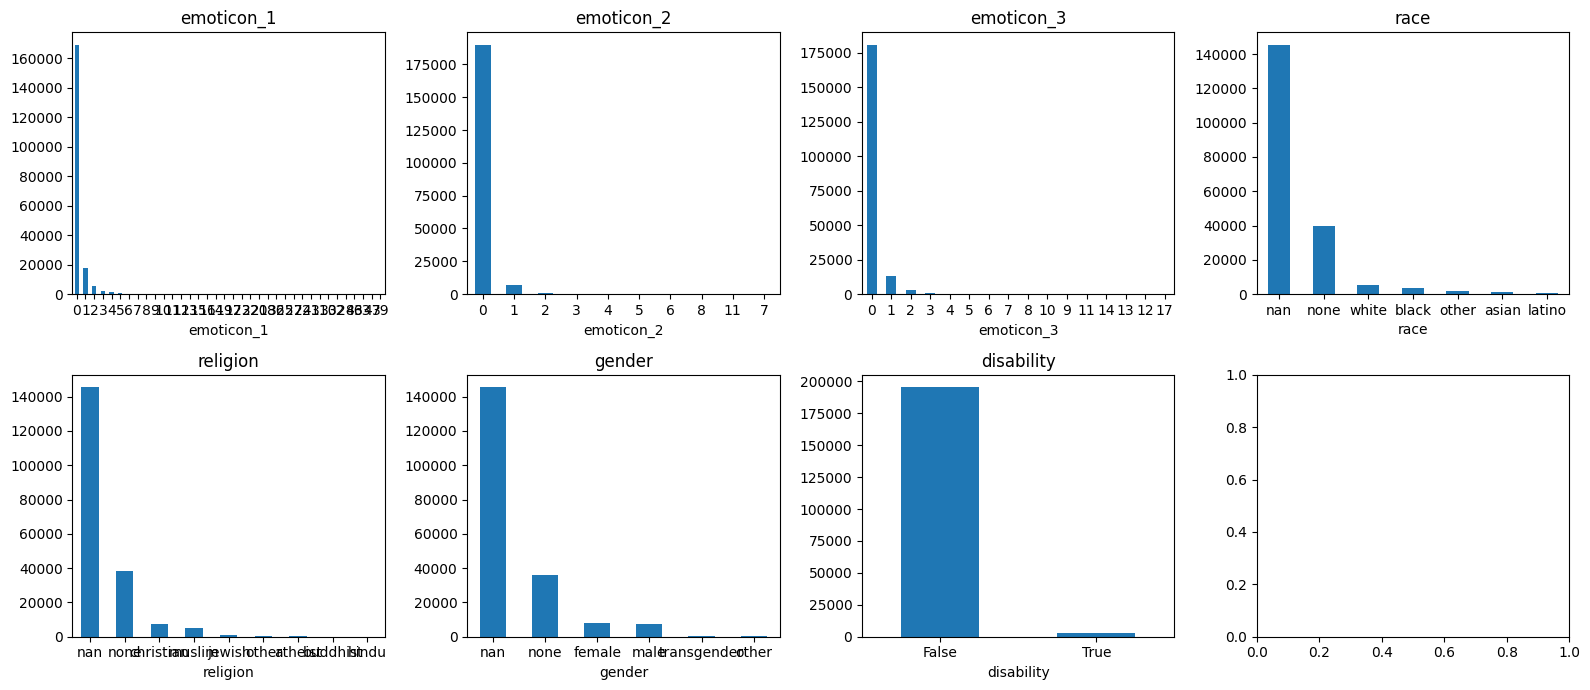

In [5]:
binary_cols = [c for c in ['emoticon_1','emoticon_2','emoticon_3','race','religion','gender','disability'] if c in train.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    train[col].astype(str).value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('binary_features.png')
plt.show()

In [6]:
def preprocess(df):
    df = df.copy()

    df['comment'] = df['comment'].fillna('').astype(str)

    for col in ['upvote', 'downvote', 'if_1', 'if_2']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())

    for col in ['emoticon_1','emoticon_2','emoticon_3','race','religion','gender','disability']:
        if col in df.columns:
            df[col] = df[col].replace('none', np.nan)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(0).astype(float)

    if 'created_date' in df.columns:
        df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
        df['hour']       = df['created_date'].dt.hour.fillna(0)
        df['dayofweek']  = df['created_date'].dt.dayofweek.fillna(0)
        df['month']      = df['created_date'].dt.month.fillna(0)
        df['is_weekend'] = (df['dayofweek'] >= 5).astype(float)

    df['comment_length']    = df['comment'].apply(len)
    df['word_count']        = df['comment'].apply(lambda x: len(x.split()))
    df['avg_word_len']      = df['comment'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    df['exclamation_count'] = df['comment'].apply(lambda x: x.count('!'))
    df['question_count']    = df['comment'].apply(lambda x: x.count('?'))
    df['upper_ratio']       = df['comment'].apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    df['net_vote']   = df['upvote'] - df['downvote']
    df['total_vote'] = df['upvote'] + df['downvote']
    df['vote_ratio'] = df['upvote'] / (df['total_vote'] + 1)

    return df

train_proc = preprocess(train)
test_proc  = preprocess(test)

print("Train:", train_proc.shape, "| Test:", test_proc.shape)

Train: (198000, 28) | Test: (102000, 27)


In [7]:
numeric_features = [
    'upvote','downvote','if_1','if_2',
    'emoticon_1','emoticon_2','emoticon_3',
    'race','religion','gender','disability',
    'comment_length','word_count','avg_word_len',
    'exclamation_count','question_count','upper_ratio',
    'net_vote','total_vote','vote_ratio',
    'hour','dayofweek','month','is_weekend'
]
numeric_features = [c for c in numeric_features if c in train_proc.columns]

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_proc[numeric_features].values)
X_num_test  = scaler.transform(test_proc[numeric_features].values)

tfidf_word = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
    dtype=np.float32
)
X_tfidf_word_train = tfidf_word.fit_transform(train_proc['comment'])
X_tfidf_word_test  = tfidf_word.transform(test_proc['comment'])
print("Word TF-IDF:", X_tfidf_word_train.shape)

tfidf_char = TfidfVectorizer(
    max_features=5000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode',
    analyzer='char_wb',
    dtype=np.float32
)
X_tfidf_char_train = tfidf_char.fit_transform(train_proc['comment'])
X_tfidf_char_test  = tfidf_char.transform(test_proc['comment'])
print("Char TF-IDF:", X_tfidf_char_train.shape)

X_train_full = hstack([X_tfidf_word_train, X_tfidf_char_train, csr_matrix(X_num_train, dtype=np.float32)])
X_test_full  = hstack([X_tfidf_word_test,  X_tfidf_char_test,  csr_matrix(X_num_test,  dtype=np.float32)])

y_train = train_proc['label'].values

print("Final train:", X_train_full.shape)
print("Final test:", X_test_full.shape)

Word TF-IDF: (198000, 10000)
Char TF-IDF: (198000, 5000)
Final train: (198000, 15024)
Final test: (102000, 15024)


In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train, test_size=0.15, random_state=42, stratify=y_train
)

X_num_tr, X_num_val, _, _ = train_test_split(
    X_num_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"Train: {X_tr.shape[0]} samples | Val: {X_val.shape[0]} samples")

Train: 168300 samples | Val: 29700 samples


In [9]:
lr = LogisticRegression(C=3.0, max_iter=1000, solver='saga', multi_class='multinomial', random_state=42, n_jobs=-1)
lr.fit(X_tr, y_tr)

lr_preds = lr.predict(X_val)
lr_acc = accuracy_score(y_val, lr_preds)
print(f"Logistic Regression — Val Accuracy: {lr_acc:.4f}")
print(classification_report(y_val, lr_preds))

Logistic Regression — Val Accuracy: 0.9061
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     17126
           1       0.78      0.71      0.75      2388
           2       0.84      0.92      0.88      9366
           3       0.75      0.48      0.59       820

    accuracy                           0.91     29700
   macro avg       0.83      0.76      0.79     29700
weighted avg       0.91      0.91      0.90     29700



In [10]:
# RF works on numeric features only to stay within memory limits
rf = RandomForestClassifier(
    n_estimators=300, max_depth=25, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1, class_weight='balanced'
)
rf.fit(X_num_tr, y_tr)

rf_preds = rf.predict(X_num_val)
rf_acc = accuracy_score(y_val, rf_preds)
print(f"Random Forest — Val Accuracy: {rf_acc:.4f}")
print(classification_report(y_val, rf_preds))

Random Forest — Val Accuracy: 0.8433
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     17126
           1       0.46      0.70      0.56      2388
           2       0.79      0.75      0.77      9366
           3       0.27      0.05      0.09       820

    accuracy                           0.84     29700
   macro avg       0.62      0.61      0.59     29700
weighted avg       0.85      0.84      0.84     29700



In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    gamma=0.1, eval_metric='mlogloss', random_state=42,
    n_jobs=-1, tree_method='hist', use_label_encoder=False
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

xgb_preds = xgb_model.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_preds)
print(f"XGBoost — Val Accuracy: {xgb_acc:.4f}")
print(classification_report(y_val, xgb_preds))

[0]	validation_0-mlogloss:1.18709
[100]	validation_0-mlogloss:0.45648
[200]	validation_0-mlogloss:0.45071
[300]	validation_0-mlogloss:0.45357
[400]	validation_0-mlogloss:0.45578
[499]	validation_0-mlogloss:0.45715
XGBoost — Val Accuracy: 0.9116
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.79      0.74      0.76      2388
           2       0.84      0.93      0.88      9366
           3       0.77      0.45      0.57       820

    accuracy                           0.91     29700
   macro avg       0.85      0.77      0.79     29700
weighted avg       0.91      0.91      0.91     29700



In [12]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.03, max_depth=8, num_leaves=127,
    subsample=0.8, colsample_bytree=0.7, min_child_samples=15,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42,
    n_jobs=-1, class_weight='balanced', verbose=-1
)
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(100)]
)

lgb_preds = lgb_model.predict(X_val)
lgb_acc = accuracy_score(y_val, lgb_preds)
print(f"LightGBM — Val Accuracy: {lgb_acc:.4f}")
print(classification_report(y_val, lgb_preds))

[100]	valid_0's multi_logloss: 0.418429
[200]	valid_0's multi_logloss: 0.364574
[300]	valid_0's multi_logloss: 0.340807
[400]	valid_0's multi_logloss: 0.325897
[500]	valid_0's multi_logloss: 0.315252
[600]	valid_0's multi_logloss: 0.307233
[700]	valid_0's multi_logloss: 0.300989
[800]	valid_0's multi_logloss: 0.295802
[900]	valid_0's multi_logloss: 0.291403
[1000]	valid_0's multi_logloss: 0.287587
LightGBM — Val Accuracy: 0.9109
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.71      0.84      0.77      2388
           2       0.88      0.88      0.88      9366
           3       0.57      0.73      0.64       820

    accuracy                           0.91     29700
   macro avg       0.79      0.85      0.81     29700
weighted avg       0.92      0.91      0.91     29700



In [13]:
best_iter = lgb_model.best_iteration_ if lgb_model.best_iteration_ > 0 else 800
print(f"Retraining with {best_iter} iterations on full data...")

lgb_full = lgb.LGBMClassifier(
    n_estimators=best_iter, learning_rate=0.03, max_depth=8, num_leaves=127,
    subsample=0.8, colsample_bytree=0.7, min_child_samples=15,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42,
    n_jobs=-1, class_weight='balanced', verbose=-1
)
lgb_full.fit(X_train_full, y_train)

lgb_full_preds = lgb_full.predict(X_val)
lgb_full_acc = accuracy_score(y_val, lgb_full_preds)
print(f"LightGBM Full — Val Accuracy: {lgb_full_acc:.4f}")
print(classification_report(y_val, lgb_full_preds))

Retraining with 1000 iterations on full data...
LightGBM Full — Val Accuracy: 0.9487
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     17126
           1       0.82      0.98      0.89      2388
           2       0.94      0.93      0.93      9366
           3       0.75      1.00      0.85       820

    accuracy                           0.95     29700
   macro avg       0.87      0.97      0.91     29700
weighted avg       0.95      0.95      0.95     29700



              Model  Val Accuracy
      LightGBM Full      0.948653
            XGBoost      0.911650
           LightGBM      0.910875
Logistic Regression      0.906061
      Random Forest      0.843266


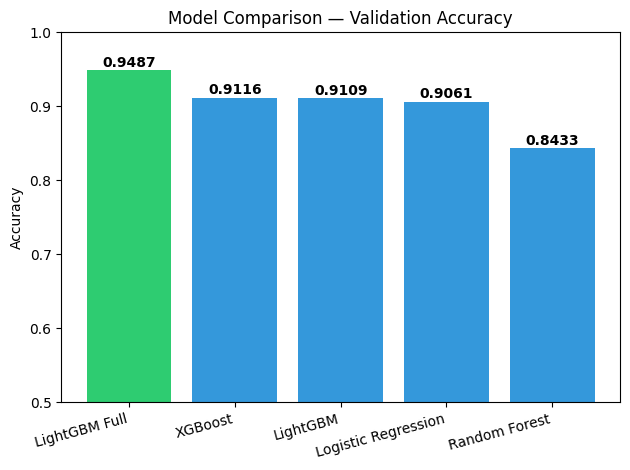

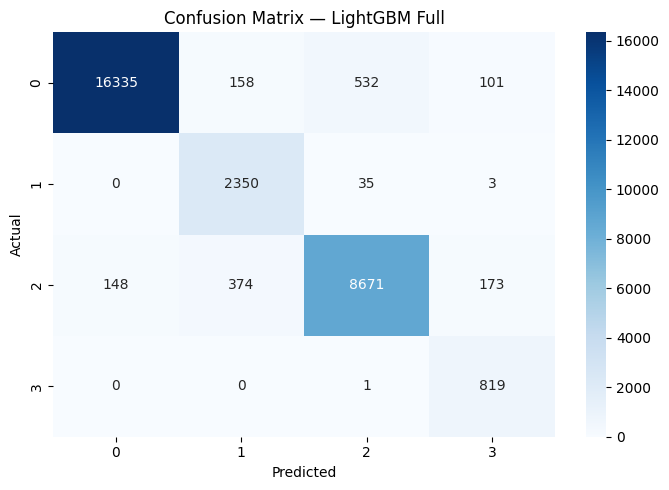

In [14]:
results = {
    'Logistic Regression': lr_acc,
    'Random Forest':       rf_acc,
    'XGBoost':             xgb_acc,
    'LightGBM':            lgb_acc,
    'LightGBM Full':       lgb_full_acc
}

results_df = pd.DataFrame(list(results.items()), columns=['Model','Val Accuracy']).sort_values('Val Accuracy', ascending=False)
print(results_df.to_string(index=False))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['Val Accuracy'], color=colors)
plt.title('Model Comparison — Validation Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, results_df['Val Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

cm = confusion_matrix(y_val, lgb_full_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — LightGBM Full')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [15]:
final_predictions = lgb_full.predict(X_test_full)

unique, counts = np.unique(final_predictions, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Label {int(u)}: {c} ({c/len(final_predictions)*100:.1f}%)")

submission = pd.DataFrame({
    'ID': sample_submission['ID'],
    'label': final_predictions.astype(int)
})
submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print(f"Total rows: {len(submission)}")

Label 0: 56638 (55.5%)
Label 1: 9592 (9.4%)
Label 2: 32083 (31.5%)
Label 3: 3687 (3.6%)
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      3
5   6      0
6   7      1
7   8      0
8   9      0
9  10      2
Total rows: 102000
